# 1.0: Exploratory Data Analysis

**Question this notebook answers:** what does the Lending Club "accepted loans" dataset
actually look like once restricted to loans with a known outcome, and why does that
restriction force a temporal, profit-based approach rather than a standard accuracy
benchmark?

> **How to run:** this is a *narrated* notebook. It loads artifacts already produced by
> the working pipeline. It does not clean data, train, or tune anything itself. Run
> `python run_all.py` from the repo root first (~3 minutes); after that, this notebook
> (and every other `N.0-*.ipynb` notebook) runs top-to-bottom in seconds. All numbers here
> come from `data/processed/*.parquet` and `docs/FACTS.md`. Nothing is recomputed from
> the raw CSV.

This is one of seven narrated notebooks (`1.0`-`7.0`) that walk through the project for a
reader. The full working process (14 notebooks, every dead end and diagnostic) lives in
`notebooks/01_...ipynb` through `14_...ipynb` and is summarized in `docs/FACTS.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'

loans_clean = pd.read_parquet(PROCESSED_DIR / 'loans_clean.parquet')
train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
validation = pd.read_parquet(PROCESSED_DIR / 'validation.parquet')
test = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
transfer_60m = pd.read_parquet(PROCESSED_DIR / 'transfer_60m.parquet')

print(f'loans_clean.parquet : {loans_clean.shape}')
print(f'train.parquet       : {train.shape}')
print(f'validation.parquet  : {validation.shape}')
print(f'test.parquet        : {test.shape}')
print(f'transfer_60m.parquet: {transfer_60m.shape}')


loans_clean.parquet : (673314, 84)
train.parquet       : (172988, 89)
validation.parquet  : (162570, 89)
test.parquet        : (282787, 89)
transfer_60m.parquet: (54969, 89)


## The population funnel

The raw file (`accepted_2007_to_2018Q4.csv`, ~1.67 GB, 2,260,701 rows, 151 columns) is
almost entirely *not usable* for this problem. Two restrictions matter more than any
cleaning step:

1. **Only loans with a concluded outcome** (`Fully Paid` or `Charged Off`) have a label.
   `Current`, `Late`, `In Grace Period`, `Default` loans are still in progress. Scoring
   them would record a prediction as if it were a fact.
2. **Only loans old enough that their term has actually elapsed.** A 36-month loan issued
   in 2018 can only appear in this data as an early payoff or an early default. Keeping
   immature vintages would bias the observed default rate downward for no good reason.

These two cuts remove **70% of the raw file**. The numbers below are quoted from
`docs/FACTS.md` §2 (independently re-verified there against the raw CSV, not recomputed
here):

In [2]:
funnel = pd.DataFrame([
    ('Total in file',                                    2_260_701, 100.00),
    ('Status Current / Late / Grace / Default / policy',   915_358,  40.49),
    ('CSV footer rows',                                          33,   0.00),
    ('Immature vintage (36m issued after Dec/2015)',        402_159,  17.79),
    ('Immature vintage (60m issued after Dec/2013)',        269_598,  11.93),
    ('Analytical population (concluded, mature)',           673_553,  29.79),
], columns=['step', 'rows', 'pct_of_raw'])
funnel


,step,rows,pct_of_raw
0,Total in file,2260701,100.00
1,Status Current / Late / Grace / Default / policy,915358,40.49
2,CSV footer rows,33,0.00
3,Immature vintage (36m issued after Dec/2015),402159,17.79
4,Immature vintage (60m issued after Dec/2013),269598,11.93
5,"Analytical population (concluded, mature)",673553,29.79


After the funnel: 5 rows with an internally impossible `dti` (> 100) and 234
joint-application rows (whose `dti` is computed on a different denominator, see `2.0`)
are also dropped, leaving the **673,314-row, 84-column** `loans_clean.parquet` loaded
above. Population default rate: **14.81%**.

## The splits are temporal, not random

The four files loaded above are not random subsets. They are cut by `issue_d`. This is
the single most consequential methodological choice in the project (detailed in `4.0`),
so it is worth seeing directly in the data rather than taking on faith:

In [3]:
splits = {'train': train, 'validation': validation, 'test': test, 'transfer_60m (60-month)': transfer_60m}
rows = []
for name, df in splits.items():
    rows.append({
        'split': name, 'N': len(df),
        'default_rate_%': round(df['target'].mean() * 100, 4),
        'issue_d_min': df['issue_d'].min().date(), 'issue_d_max': df['issue_d'].max().date(),
        'term': sorted(df['term'].unique()),
    })
pd.DataFrame(rows).set_index('split')


,N,default_rate_%,issue_d_min,issue_d_max,term
split,,,,,
train,172988,12.4332,2007-06-01,2013-12-01,[36.0]
validation,162570,13.7264,2014-01-01,2014-12-01,[36.0]
test,282787,14.8836,2015-01-01,2015-12-01,[36.0]
transfer_60m (60-month),54969,25.1596,2010-05-01,2013-12-01,[60.0]


Two things stand out, both foreshadowed here and resolved later:

- **Default rate rises monotonically from train to validation to test** (12.43% to 13.73% to
  14.88%). This is a real vintage trend in the data, not an artifact. It means a
  model validated on 2014 and tested on 2015 is being asked to generalize across a
  genuinely shifting base rate, not an i.i.d. sample.
- **The 60-month population (`transfer_60m`) defaults far more often** (25.16% vs.
  ~13-15% for 36-month loans) and covers an entirely different, earlier date range
  (2010-2013). It is held out and used only once a model is chosen (`6.0`), never for
  training or tuning.

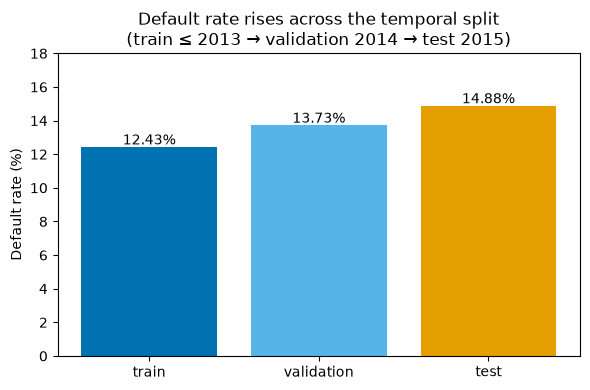

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ['train', 'validation', 'test']
rates = [train['target'].mean() * 100, validation['target'].mean() * 100, test['target'].mean() * 100]
ax.bar(order, rates, color=['#0072B2', '#56B4E9', '#E69F00'])
ax.set_ylabel('Default rate (%)')
ax.set_title('Default rate rises across the temporal split\n(train ≤ 2013 → validation 2014 → test 2015)')
for i, r in enumerate(rates):
    ax.text(i, r + 0.15, f'{r:.2f}%', ha='center')
ax.set_ylim(0, 18)
plt.tight_layout()
plt.show()


## Takeaway

The population is small relative to the raw file (673K of 2.26M rows) because only
concluded, matured loans carry a real label, and the outcome rate is not stationary
across time. Both facts rule out a random train/test split (§`4.0`) and rule out treating
this as an ordinary i.i.d. classification benchmark: any validation scheme that shuffles
across `issue_d` would silently let 2015 information leak into a model evaluated as if it
only knew the past.

**Next:** `2.0-cleaning.ipynb`: how missing data was diagnosed by *mechanism* (not just
imputed by convention), and how leakage was screened out on the target and identity
fronts.